# Advanced PPG Derivatives & HRV Feature Engineering for BGL Estimation

This notebook implements an advanced clinical feature engineering pipeline to extract features from the original PPG wave, its **first derivative (Velocity PPG - VPG)**, and its **second derivative (Acceleration PPG - APG)**, alongside standard **Pulse Rate Variability (PRV)** metrics. 

These features are mapped against Blood Glucose Levels (BGL) collected in `data/real/glucosense_r_dataset_2026-08-27.csv` and modeled using multiple cross-validated regressors to evaluate true generalization performance.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

csv_path = "data/real/glucosense_r_dataset_2026-09-04.csv"
sampling_rate = 50  # 50 Hz
print("✓ Imports completed. Dataset configuration defined.")

✓ Imports completed. Dataset configuration defined.


## 1. APG Wave Peak Localization & Compliance Feature Extractor
We define a robust algorithm to segment trough-to-trough pulses and find the five key APG systolic and diastolic waves ($a$, $b$, $c$, $d$, $e$ peaks) to calculate clinical ratios.

In [ ]:
def extract_pulse_apg_features(apg_segment):
    """
    Extracts systolic and diastolic peaks (a, b, c, d, e) from an Acceleration PPG segment
    and calculates vascular elasticity and compliance ratios.
    """
    n = len(apg_segment)
    if n < 10:
        return None
        
    try:
        # 1. a wave (early systolic peak): max in the first 30% of the cycle
        limit_a = max(3, int(n * 0.3))
        idx_a = np.argmax(apg_segment[:limit_a])
        val_a = apg_segment[idx_a]
        
        # 2. b wave (early systolic deceleration trough): min following a, within first 50%
        limit_b = max(idx_a + 2, int(n * 0.5))
        if limit_b <= idx_a + 1 or limit_b > n:
            return None
        idx_b = idx_a + 1 + np.argmin(apg_segment[idx_a + 1 : limit_b])
        val_b = apg_segment[idx_b]
        
        # 3. c wave (late systolic acceleration peak): max following b, within first 65%
        limit_c = max(idx_b + 2, int(n * 0.65))
        if limit_c <= idx_b + 1 or limit_c > n:
            return None
        idx_c = idx_b + 1 + np.argmax(apg_segment[idx_b + 1 : limit_c])
        val_c = apg_segment[idx_c]
        
        # 4. d wave (late systolic deceleration trough): min following c, within first 80%
        limit_d = max(idx_c + 2, int(n * 0.8))
        if limit_d <= idx_c + 1 or limit_d > n:
            return None
        idx_d = idx_c + 1 + np.argmin(apg_segment[idx_c + 1 : limit_d])
        val_d = apg_segment[idx_d]
        
        # 5. e wave (diastolic peak): max following d
        if idx_d + 1 >= n:
            val_e = val_d
        else:
            idx_e = idx_d + 1 + np.argmax(apg_segment[idx_d + 1 :])
            val_e = apg_segment[idx_e]
            
        # Ensure a wave is not zero or extremely tiny to avoid division by zero
        if abs(val_a) < 1e-6:
            return None
            
        return {
            'b_a_ratio': val_b / val_a,
            'c_a_ratio': val_c / val_a,
            'd_a_ratio': val_d / val_a,
            'e_a_ratio': val_e / val_a,
            'aging_index': (val_b - val_c - val_d - val_e) / val_a,
            'elasticity_index': (val_b - val_e) / val_a,
            'deceleration_index': (val_b - val_c - val_d) / val_a,
            'reflected_index': (val_c + val_d - val_b) / val_a
        }
    except Exception:
        return None
print("✓ APG feature extraction algorithm successfully defined.")

✓ APG feature extraction algorithm successfully defined.


## 2. Load Dataset & Execute Segmented Pulse Analysis
We clean each session's waveform, calculate its VPG and APG waves, segment pulses, extract average compliance ratios, and extract standard PRV/HRV metrics.

In [ ]:
df = pd.read_csv(csv_path)
features_list = []
skipped_count = 0

print(f"Processing {len(df)} database records...")

for idx, row in df.iterrows():
    if pd.isna(row['bgl_mgdl']) or pd.isna(row['ppg_data']):
        skipped_count += 1
        continue
        
    try:
        # Parse PPG data
        ppg_signal = np.array([float(x) for x in str(row['ppg_data']).split(';') if x.strip()])
        
        # We need a full 60-second window + 10s stabilization
        if len(ppg_signal) < 3500:
            skipped_count += 1
            continue
            
        # Slice stable 60-second window
        active_signal = ppg_signal[500:3500]
        
        # Preprocess PPG signal
        cleaned = nk.ppg_clean(active_signal, sampling_rate=sampling_rate, method='elgendi')
        
        # 1st and 2nd derivatives (VPG and APG)
        vpg = np.gradient(cleaned)
        apg = np.gradient(vpg)
        
        # Detect systolic peaks
        signals, info = nk.ppg_process(active_signal, sampling_rate=sampling_rate, method='elgendi')
        peaks = info['PPG_Peaks']
        
        # Segment pulses from trough to trough around each peak
        session_apg_ratios = []
        
        for i in range(1, len(peaks) - 1):
            # Start trough: local min in PPG signal between peak_i-1 and peak_i
            start_trough = peaks[i-1] + np.argmin(cleaned[peaks[i-1] : peaks[i]])
            # End trough: local min in PPG signal between peak_i and peak_i+1
            end_trough = peaks[i] + np.argmin(cleaned[peaks[i] : peaks[i+1]])
            
            apg_pulse_segment = apg[start_trough:end_trough]
            apg_feats = extract_pulse_apg_features(apg_pulse_segment)
            if apg_feats is not None:
                session_apg_ratios.append(apg_feats)
                
        if len(session_apg_ratios) < 5:
            # Not enough valid pulses segmented
            skipped_count += 1
            continue
            
        # Average APG ratios across all valid pulses
        avg_apg_ratios = pd.DataFrame(session_apg_ratios).mean().to_dict()
        
        # Calculate HRV features via NeuroKit2
        analyzed_hrv = nk.ppg_analyze(signals, sampling_rate=sampling_rate)
        
        # Build baseline session feature row
        feat_row = {
            'participant_id': row['participant_id'],
            'session_kind': row['session_kind'],
            'age': row['age'],
            'weight_kg': row['weight_kg'],
            'height_cm': row['height_cm'],
            'years_on_t2dm': row['years_on_t2dm'],
            'bgl_mgdl': float(row['bgl_mgdl']),
            # Raw PPG waveform descriptors
            'ppg_amp': np.std(cleaned),
            'ppg_skew': skew(cleaned),
            'ppg_kurt': kurtosis(cleaned),
            # VPG descriptors
            'vpg_amp': np.std(vpg),
            'vpg_skew': skew(vpg),
            'vpg_kurt': kurtosis(vpg),
            # APG descriptors
            'apg_amp': np.std(apg),
            'apg_skew': skew(apg),
            'apg_kurt': kurtosis(apg),
        }
        
        # Add APG compliance ratios
        feat_row.update(avg_apg_ratios)
        
        # Add specific standard HRV/PRV time-domain metrics
        target_hrv_metrics = ['PPG_Rate_Mean', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_pNN20', 'HRV_pNN50']
        for metric in target_hrv_metrics:
            if metric in analyzed_hrv.columns:
                val = analyzed_hrv[metric].values[0]
                if not pd.isna(val):
                    feat_row[metric] = val
                    
        features_list.append(feat_row)
    except Exception as e:
        print(f"❌ Row {idx} failed: {e}")
        skipped_count += 1

feat_df = pd.DataFrame(features_list)

# Handle infinite replacements and completely empty features
feat_df.replace([np.inf, -np.inf], np.nan, inplace=True)
feat_df.dropna(axis=1, how='all', inplace=True)

print(f"\n✓ Processing complete. Successfully analyzed {len(feat_df)} sessions. Skipped {skipped_count} sessions.")

Processing 39 database records...


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for th


✓ Processing complete. Successfully analyzed 39 sessions. Skipped 0 sessions.


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


## 3. Robust Correlation Matrix & Analysis
We calculate the Pearson correlation coefficients ($r$) of our newly engineered compliance and derivative features with Blood Glucose Levels, and render a heatmap.

--- Advanced Features Correlation Table (Sorted by absolute strength) ---


,Pearson_r,Absolute_r
height_cm,-0.395652,0.395652
e_a_ratio,0.252805,0.252805
HRV_SDNN,-0.247245,0.247245
c_a_ratio,-0.243980,0.243980
HRV_pNN20,-0.231427,0.231427
HRV_CVNN,-0.229254,0.229254
b_a_ratio,0.228942,0.228942
HRV_pNN50,-0.223885,0.223885
HRV_SDSD,-0.215778,0.215778
HRV_RMSSD,-0.215673,0.215673


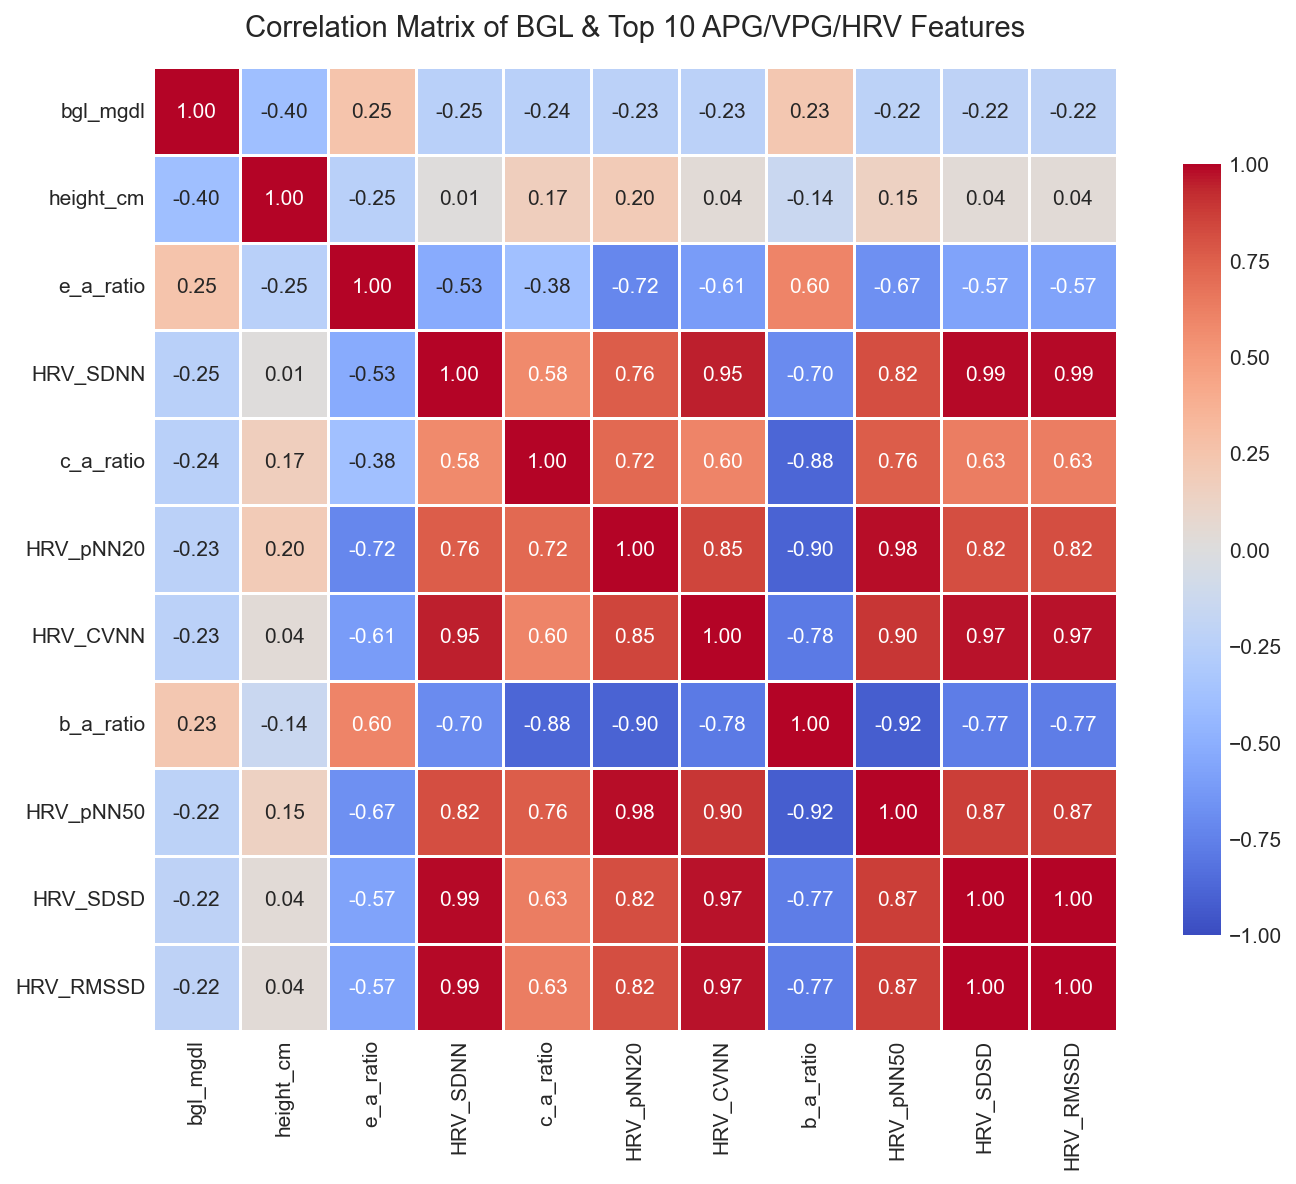

In [4]:
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = feat_df[numeric_cols].corr()

# Sorted correlations with BGL
bgl_corr = corr_matrix['bgl_mgdl'].drop('bgl_mgdl')
bgl_corr_sorted = bgl_corr.abs().sort_values(ascending=False)
bgl_corr_signed = bgl_corr[bgl_corr_sorted.index]

corr_df = pd.DataFrame({
    'Pearson_r': bgl_corr_signed,
    'Absolute_r': bgl_corr_sorted
})

print("--- Advanced Features Correlation Table (Sorted by absolute strength) ---")
display(corr_df)

# Plot heatmap of the top 10 most correlated engineered features against BGL
top_feats = bgl_corr_sorted.head(10).index.tolist()
heatmap_cols = ['bgl_mgdl'] + top_feats
sub_corr_matrix = corr_matrix.loc[heatmap_cols, heatmap_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(
    sub_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix of BGL & Top 10 APG/VPG/HRV Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 4. Multi-Model Cross-Validation & Generalization Assessment
We evaluate multiple models using 5-Fold Cross-Validation on these engineered features to assess the true validation metrics (MAE, RMSE, $R^2$).

In [5]:
# Define features to model (all engineered VPG, APG, and HRV metrics)
model_features = [col for col in numeric_cols if col not in ['bgl_mgdl', 'age', 'weight_kg', 'height_cm', 'years_on_t2dm']]

print(f"Features included in the ML modeling matrix ({len(model_features)} features):")
print(model_features)

X = feat_df[model_features].values
y = feat_df['bgl_mgdl'].values

# We will test three popular models: Linear Regression, Random Forest, and Gradient Boosting
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=20, max_depth=4, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=15, max_depth=3, learning_rate=0.1, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    print(f"\n=== Cross-Validating {model_name} ===")
    maes, rmses, r2s = [], [], []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Impute both NaNs and Infs robustly within each fold
        X_train_clean = np.where(np.isinf(X_train), np.nan, X_train)
        col_means = np.nanmean(X_train_clean, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        
        X_train_imp = np.where(np.isnan(X_train) | np.isinf(X_train), col_means, X_train)
        X_val_imp = np.where(np.isnan(X_val) | np.isinf(X_val), col_means, X_val)
        
        model.fit(X_train_imp, y_train)
        preds = model.predict(X_val_imp)
        
        mae = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2 = r2_score(y_val, preds)
        
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
        
        print(f"  Fold {fold+1}: MAE = {mae:.2f} mg/dL | RMSE = {rmse:.2f} mg/dL | R^2 = {r2:.3f}")
        
    print(f"=> Average MAE:  {np.mean(maes):.2f} mg/dL")
    print(f"=> Average RMSE: {np.mean(rmses):.2f} mg/dL")
    print(f"=> Average R^2:  {np.mean(r2s):.3f}")

Features included in the ML modeling matrix (26 features):
['ppg_amp', 'ppg_skew', 'ppg_kurt', 'vpg_amp', 'vpg_skew', 'vpg_kurt', 'apg_amp', 'apg_skew', 'apg_kurt', 'b_a_ratio', 'c_a_ratio', 'd_a_ratio', 'e_a_ratio', 'aging_index', 'elasticity_index', 'deceleration_index', 'reflected_index', 'PPG_Rate_Mean', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_pNN20', 'HRV_pNN50']

=== Cross-Validating Linear Regression ===
  Fold 1: MAE = 106.44 mg/dL | RMSE = 151.11 mg/dL | R^2 = -13.207
  Fold 2: MAE = 141.70 mg/dL | RMSE = 187.45 mg/dL | R^2 = -3.842
  Fold 3: MAE = 111.01 mg/dL | RMSE = 137.67 mg/dL | R^2 = -4.872
  Fold 4: MAE = 85.28 mg/dL | RMSE = 111.32 mg/dL | R^2 = -3.379
  Fold 5: MAE = 57.57 mg/dL | RMSE = 63.73 mg/dL | R^2 = -2.810
=> Average MAE:  100.40 mg/dL
=> Average RMSE: 130.26 mg/dL
=> Average R^2:  -5.622

=== Cross-Validating Random Forest ===
  Fold 1: MAE = 27.46 mg/dL | RMSE = 44.09 mg/dL | R^2 = -0.210
  Fold 2: MAE = 58.71 mg/dL |

## 5. Final Model Fit and Plotting
We train the model on the full pilot dataset and visualize the predicted vs. measured Blood Glucose Levels.

Final Model Performance (Full Dataset Fit):
Training MAE: 26.25 mg/dL
Training R^2: 0.714


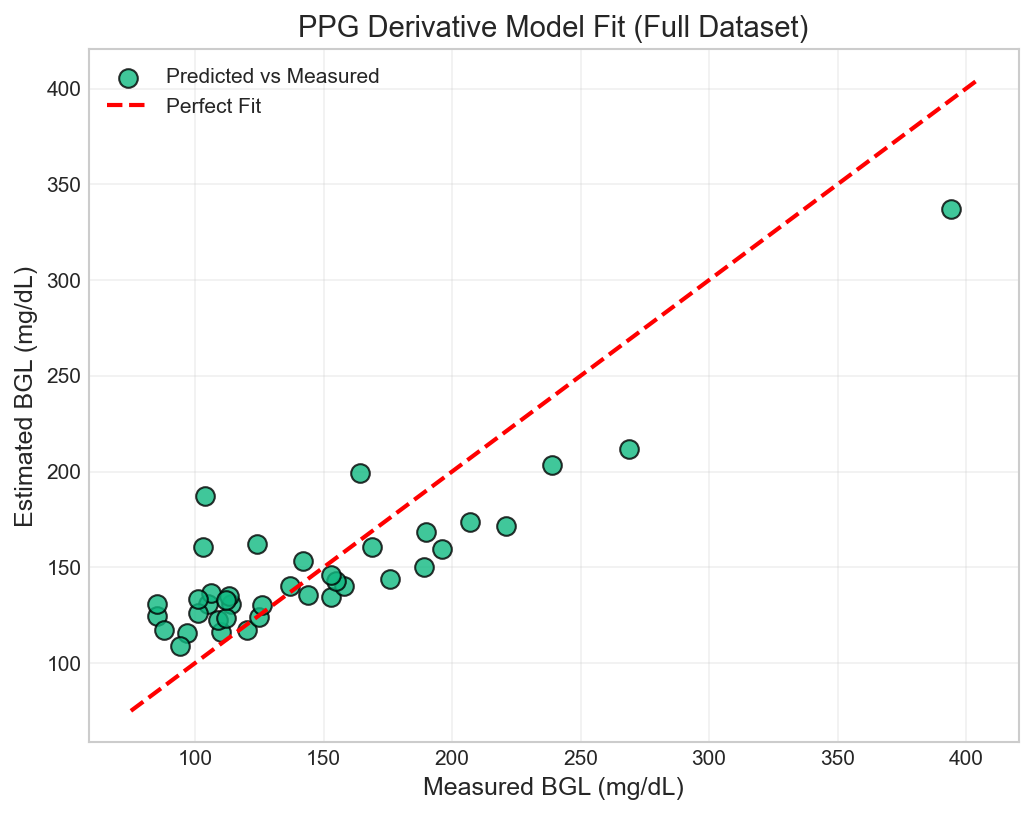

In [6]:
# Impute NaNs and Infs globally
X_clean = np.where(np.isinf(X), np.nan, X)
col_means = np.nanmean(X_clean, axis=0)
col_means = np.where(np.isnan(col_means), 0.0, col_means)
X_imp = np.where(np.isnan(X) | np.isinf(X), col_means, X)

# Fit Random Forest on all available real data
final_model = RandomForestRegressor(n_estimators=20, max_depth=4, random_state=42)
final_model.fit(X_imp, y)
preds = final_model.predict(X_imp)

print("Final Model Performance (Full Dataset Fit):")
print(f"Training MAE: {mean_absolute_error(y, preds):.2f} mg/dL")
print(f"Training R^2: {r2_score(y, preds):.3f}")

# Plot predictions vs measured
plt.figure(figsize=(8, 6))
plt.scatter(y, preds, color='#10b981', alpha=0.8, edgecolors='k', s=80, label='Predicted vs Measured')
plt.plot([y.min()-10, y.max()+10], [y.min()-10, y.max()+10], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Measured BGL (mg/dL)', fontsize=12)
plt.ylabel('Estimated BGL (mg/dL)', fontsize=12)
plt.title('PPG Derivative Model Fit (Full Dataset)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()